# **Automotive Price Prediction & Market Intelligence System**
Built an end-to-end machine learning system to predict European car prices using regression models. Performed data cleaning, feature engineering, categorical encoding, and trained multiple models including Linear Regression, Lasso, Ridge, Random Forest and XGBoost. Evaluated and compared the models performance using MSE, RMSE and R², with XGBoost achieving the best results. Generated market insights by analyzing feature importance and relationships between vehicle performance, safety, efficiency, and price.
##### **Dataset:** https://www.kaggle.com/datasets/eswarpanchakarla/european-cars-dataset

## **Importing libraries and loading the dataset**

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import plot_importance

In [49]:
data = pd.read_excel('European_cars_dataset.xlsx')
data.head()

,Model Name,Brand,Body Type,Segment,Usable Battery (kWh),Real Range (km),Efficiency (Wh/km),0–100 km/h (s),Top Speed (km/h),Towing Capacity (kg),...,Maintenance Cost (€/year),Seating Capacity,Boot Capacity (L),ADAS Level,Safety Rating (Euro NCAP),Usage Type,Energy Cost (€/100km),Insurance Rating,Powertrain Type,Fuel Type
0,Kia R7 Pro,Kia,Sedan,D,0.0,700,700.0,8.9,250,854,...,562,5,422,2,4,Personal,13.89,5,Petrol,Petrol
1,Fiat T-Class,Fiat,Crossover,D,0.0,929,617.0,10.0,212,1482,...,466,7,537,1,3,Personal,10.17,2,Diesel,Diesel
2,Mini P8x,Mini,Wagon,B,1.7,900,421.0,9.7,238,1212,...,609,5,740,1,4,Personal,7.24,5,Hybrid,Petrol+Electric
3,Honda F3x,Honda,Hatchback,A,0.0,782,467.0,11.7,189,865,...,499,5,341,0,3,Personal,8.92,3,Petrol,Petrol
4,BMW E8 Pro,BMW,Hatchback,C,1.3,900,312.0,10.7,212,811,...,511,5,465,0,3,Personal,5.36,2,Hybrid,Petrol+Electric


In [50]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Model Name                 6000 non-null   str    
 1   Brand                      6000 non-null   str    
 2   Body Type                  6000 non-null   str    
 3   Segment                    6000 non-null   str    
 4   Usable Battery (kWh)       6000 non-null   float64
 5   Real Range (km)            6000 non-null   int64  
 6   Efficiency (Wh/km)         6000 non-null   float64
 7   0–100 km/h (s)             6000 non-null   float64
 8   Top Speed (km/h)           6000 non-null   int64  
 9   Towing Capacity (kg)       6000 non-null   int64  
 10  Price (EUR)                6000 non-null   int64  
 11  Charging Time (min)        6000 non-null   int64  
 12  Max Charging Power (kW)    6000 non-null   int64  
 13  Horsepower (HP)            6000 non-null   int64  
 14  Tor

## **Data Cleaning & Preprocessing**

In [51]:
#Removing identifier column
data = data.drop(columns=["Model Name"], errors="ignore")   #errors="ignore": if column exists → remove it; if not → don’t crash

In [52]:
data.shape

(6000, 24)

In [53]:
#Duplicate check
data.duplicated().sum()

#No duplicates detected


#Removing duplicate rows
#data = data.drop_duplicates() 
#print("Dataset shape after duplicate removal:", data.shape) 

np.int64(0)

In [54]:
#Missing values check
data.isnull().sum()

#No missing values detected


#Handling missing values
#num_cols = data.select_dtypes(include=["int64", "float64"]).columns
#cat_cols = data.select_dtypes(include=["object", "string"]).columns
#data[num_cols] = data[num_cols].fillna(data[num_cols].median())

Brand                        0
Body Type                    0
Segment                      0
Usable Battery (kWh)         0
Real Range (km)              0
Efficiency (Wh/km)           0
0–100 km/h (s)               0
Top Speed (km/h)             0
Towing Capacity (kg)         0
Price (EUR)                  0
Charging Time (min)          0
Max Charging Power (kW)      0
Horsepower (HP)              0
Torque (Nm)                  0
Maintenance Cost (€/year)    0
Seating Capacity             0
Boot Capacity (L)            0
ADAS Level                   0
Safety Rating (Euro NCAP)    0
Usage Type                   0
Energy Cost (€/100km)        0
Insurance Rating             0
Powertrain Type              0
Fuel Type                    0
dtype: int64

In [55]:
#Outlier handling
target = "Price (EUR)"

#IQR (Interquartile Range method) - statistical technique used to measure data spread and identify outliers (extreme values) in a dataset
Q1 = data[target].quantile(0.25)
Q3 = data[target].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

data = data[(data[target] >= lower) & (data[target] <= upper)]

## **Feature Engineering**
##### **Creating high-value engineering features**

In [56]:
#make ADAS safe numeric (prevents .str error)
data["ADAS Level"] = pd.to_numeric(data["ADAS Level"], errors="coerce")   # pd.to_numeric(..., errors="coerce"); converts everything safely into numbers; if something is weird → becomes NaN instead of crashing

#Handling ADAS missing values
data["ADAS Level"] = data["ADAS Level"].fillna(data["ADAS Level"].median())

In [57]:
#Power-to-Weight Style Feature (performance strength)
data["Power_Torque_Score"] = data["Horsepower (HP)"] + (data["Torque (Nm)"] / 10)

#Efficiency Score (EV relevance)
data["Efficiency_Score"] = data["Real Range (km)"] / (data["Efficiency (Wh/km)"] + 1e-6)

#Safety intelligence score
data["Safety_Tech_Score"] = (
    data["Safety Rating (Euro NCAP)"] + data["ADAS Level"])

In [58]:
#ONE-HOT ENCODING (converts categorical text data into numbers so machine learning models can understand it; works if there is no Model name, ID-like column...)
data = pd.get_dummies(data, drop_first=True)


#Manual way (safer for complexity)
#categorical_cols = data.select_dtypes(include=["object", "string"]).columns   #Converts cat data into numbers
#data = pd.get_dummies(data, columns=categorical_cols, drop_first=True)

In [59]:
#Final dataset for modeling
X = data.drop(columns=["Price (EUR)"])   #everything the model is allowed to know before it predicts the price.
y = data["Price (EUR)"]   #the actual price it must learn to predict.

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [60]:
#Feature Scaling 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## **Ml Models Building**

### **Linear Regression**

In [61]:
#Initializing Linear Regression
linear = LinearRegression()

In [62]:
#Model training
linear.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](95,)","[2444.16, -70.75,-533.38,..., -83.41,-346.33, 212.91]"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.644e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,95
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(88)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](95,)","[217.57,140.14,126.79,..., 0. , 0. , 0. ]"


In [63]:
#Predict and evaluate
li_prediction = linear.predict(X_test_scaled)

print("Linear Regression Model")
print(f"MSE: {mean_squared_error(y_test, li_prediction):.3f}")
print(f"R2: {r2_score(y_test, li_prediction):.3f}")

Linear Regression Model
MSE: 9712988.415
R2: 0.963


### **Lasso Regression**

In [64]:
#Initializing Lasso
lasso = Lasso()

In [65]:
#Model training
lasso.fit(X_train_scaled, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary <warm_start>`.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'
Name,Type,Value


In [66]:
#Predict and evaluate
la_prediction = lasso.predict(X_test_scaled)

print("Lasso Regression Model")
print(f"MSE: {mean_squared_error(y_test, la_prediction):.3f}")
print(f"R2: {r2_score(y_test, la_prediction):.3f}")

Lasso Regression Model
MSE: 9708630.739
R2: 0.963


### **Ridge Regression**

In [67]:
#Initializing Ridge
ridge = Ridge()

In [68]:
#Model training
ridge.fit(X_train_scaled, y_train)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [69]:
#Predict and evaluate
ri_prediction = ridge.predict(X_test_scaled)

print("Ridge Regression Model")
print(f"MSE: { mean_squared_error(y_test, ri_prediction):.3f}")
print(f"R2: {r2_score(y_test, ri_prediction):.3f}")

Ridge Regression Model
MSE: 9716450.817
R2: 0.963


### **Random Forest**

In [70]:
#Initializing Random Forest
rf = RandomForestRegressor(max_depth=5, n_estimators=200, n_jobs=-1, random_state = 42)

In [71]:
#Model training
rf.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

In [72]:
#Predict and evaluate
rf_predictions = rf.predict(X_test)

print(f"MSE: { mean_squared_error(y_test, rf_predictions):.3f}")
print(f"R2: {r2_score(y_test, rf_predictions):.3f}")

MSE: 19913879.329
R2: 0.923


In [73]:
np.sqrt(mean_squared_error(y_test, rf_predictions))

np.float64(4462.496983595131)

### **XGBoost**

In [74]:
#Initializing XGBoost
xgb = XGBRegressor(max_depth=5, n_estimators=200, learning_rate=0.15, n_jobs=-1, random_state = 42)

In [75]:
#Model training
xgb.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [76]:
#Predict and evaluate
xgb_predictions = xgb.predict(X_test)

print(f"MSE: { mean_squared_error(y_test, xgb_predictions):.3f}")
print(f"R2: {r2_score(y_test, xgb_predictions):.3f}")

MSE: 9089852.000
R2: 0.965


In [77]:
np.sqrt(mean_squared_error(y_test, xgb_predictions))

np.float64(3014.9381419856695)

In [78]:
"Price (EUR)" in X.columns

False

## **ML Models Comparing**

In [79]:
#Final Comparison between the Models
results = pd.DataFrame({
    "Model": ["Linear Regression", "Lasso Regression", "Ridge Regression", "Random Forest", "XGBRegressor"],
    "MSE": [
        mean_squared_error(y_test, li_prediction),
        mean_squared_error(y_test, la_prediction),
        mean_squared_error(y_test, ri_prediction),
        mean_squared_error(y_test, rf_predictions),
        mean_squared_error(y_test, xgb_predictions)
    ],

    "RMSE": [ 
        np.sqrt(mean_squared_error(y_test, li_prediction)),
        np.sqrt(mean_squared_error(y_test, la_prediction)), 
        np.sqrt(mean_squared_error(y_test, ri_prediction)), 
        np.sqrt(mean_squared_error(y_test, rf_predictions)), 
        np.sqrt(mean_squared_error(y_test, xgb_predictions)) 
        ],

    "R2 Score": [
        r2_score(y_test, li_prediction),
        r2_score(y_test, la_prediction),
        r2_score(y_test, ri_prediction),
        r2_score(y_test, rf_predictions),
        r2_score(y_test, xgb_predictions),
    ]
})

print(results.round(3))

               Model           MSE      RMSE  R2 Score
0  Linear Regression  9.712988e+06  3116.567     0.963
1   Lasso Regression  9.708631e+06  3115.868     0.963
2   Ridge Regression  9.716451e+06  3117.122     0.963
3      Random Forest  1.991388e+07  4462.497     0.923
4       XGBRegressor  9.089852e+06  3014.938     0.965


## **Visualization**

<Axes: >

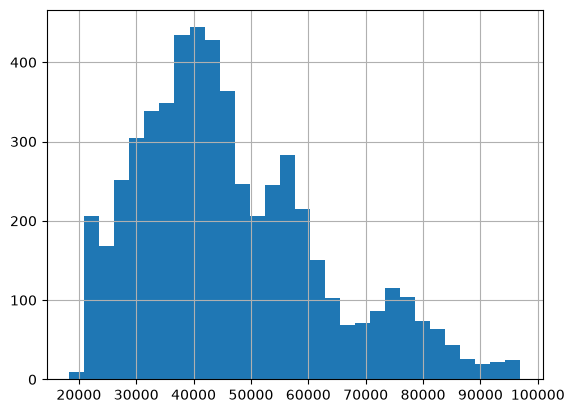

In [80]:
data["Price (EUR)"].hist(bins=30)

<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

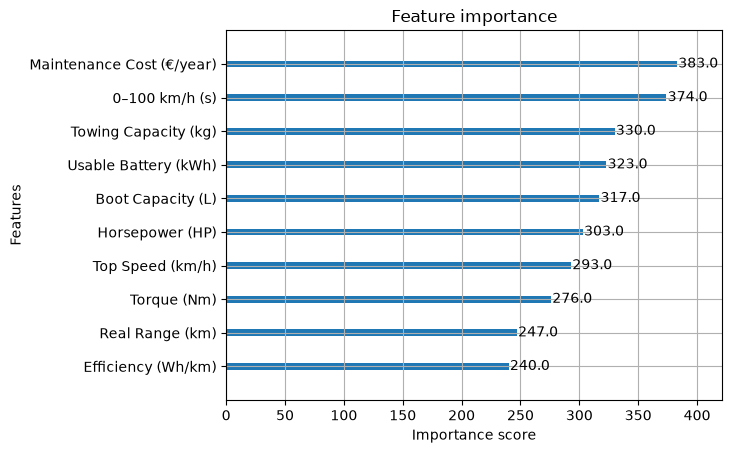

In [81]:
plot_importance(xgb, max_num_features=10)

<Axes: xlabel='Model'>

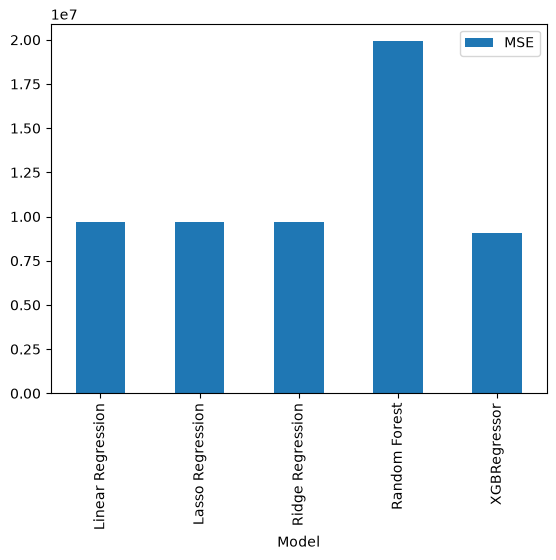

In [82]:
results.plot(x="Model", y="MSE", kind="bar")

<Axes: xlabel='Model'>

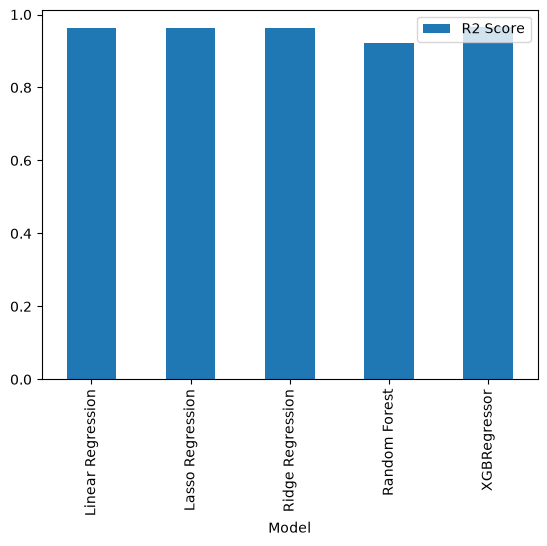

In [83]:
results.plot(x="Model", y="R2 Score", kind="bar")

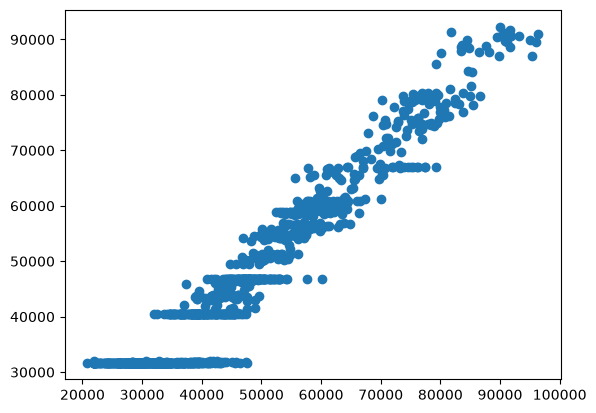

In [84]:
plt.scatter(y_test, rf_predictions)

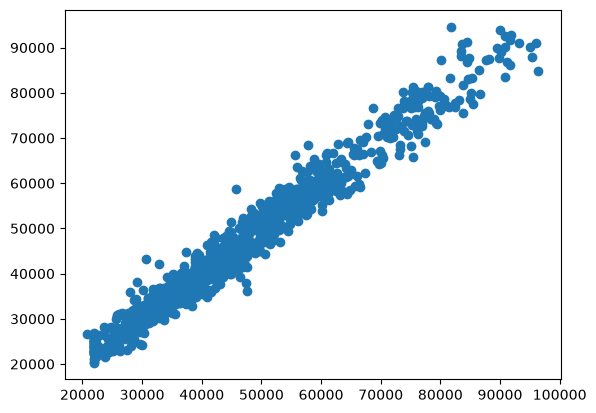

In [85]:
plt.scatter(y_test, xgb_predictions)

<Axes: >

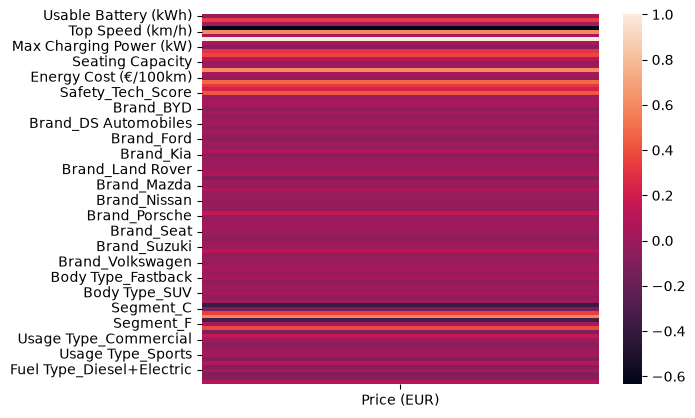

In [86]:
sns.heatmap(data.corr(numeric_only=True)[["Price (EUR)"]])